# Object Identification Notebook

In [16]:
import glob
import corner
import sep

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import pandas as pd
import numpy as np

from astropy.table import Table, hstack
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.convolution import convolve_fft, Gaussian2DKernel
from astropy.nddata import block_reduce

from photutils.detection import find_peaks

from bt_functions import grab_image, add_noise, plot_object, reduce, get_scale_pkpc, get_scale_as


In [2]:
# ---------------------------
# -------- LOAD DATA --------
# ---------------------------

# redshift 7 is the default
# BlueTides data covers redshifts 7-12
redshift = 7

jwst_path = '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_*/hlsp_bluetides_jwst_nircam_z{redshift}*_f*w_v1_sim-*.fits'
euclid_path = '/Volumes/SeagateBack/bluetides/euclid_*/hlsp_bluetides_euclid_nisp_z{redshift}*_sim-nopsf.fits'
img_path = '/Volumes/SeagateBack/bluetides/plots'
code_path = '/Volumes/SeagateBack/bluetides/code'

filenames = glob.glob(euclid_path.format(redshift=redshift))       # finds all files in path with given format 
print("Number of files:",len(filenames))                        # there are 56 files in total for z=7

catalog = Table.read('/Volumes/SeagateBack/bluetides/code/og_catalog.ecsv')
catalog[:10]

Number of files: 12


id,redshift,fileNumber,extensionNumber,stellarMass,BHmass,BHluminosity,haloMass,lum_FUV,flux_jwst.nircam.f090w,radius_jwst.nircam.f090w,flux_jwst.nircam.f115w,radius_jwst.nircam.f115w,flux_jwst.nircam.f150w,radius_jwst.nircam.f150w,flux_jwst.nircam.f200w,radius_jwst.nircam.f200w,flux_jwst.nircam.f277w,radius_jwst.nircam.f277w,flux_jwst.nircam.f356w,radius_jwst.nircam.f356w,flux_jwst.nircam.f410m,radius_jwst.nircam.f410m,flux_jwst.nircam.f444w,radius_jwst.nircam.f444w,flux_jwst.miri.f560w,radius_jwst.miri.f560w,flux_jwst.miri.f770w,radius_jwst.miri.f770w,flux_hst.wfc3.f105w,radius_hst.wfc3.f105w,flux_hst.wfc3.f125w,radius_hst.wfc3.f125w,flux_hst.wfc3.f140w,radius_hst.wfc3.f140w,flux_hst.wfc3.f160w,radius_hst.wfc3.f160w,flux_euclid.nisp.y,radius_euclid.nisp.y,flux_euclid.nisp.j,radius_euclid.nisp.j,flux_euclid.nisp.h,radius_euclid.nisp.h,flux_roman.wfi.f087,radius_roman.wfi.f087,flux_roman.wfi.f106,radius_roman.wfi.f106,flux_roman.wfi.f129,radius_roman.wfi.f129,flux_roman.wfi.f146,radius_roman.wfi.f146,flux_roman.wfi.f158,radius_roman.wfi.f158,flux_roman.wfi.f184,radius_roman.wfi.f184,flux_subaru.hsc.z,radius_subaru.hsc.z,flux_subaru.hsc.y,radius_subaru.hsc.y,flux_vista.vircam.z,radius_vista.vircam.z,flux_vista.vircam.y,radius_vista.vircam.y,flux_vista.vircam.j,radius_vista.vircam.j,flux_vista.vircam.h,radius_vista.vircam.h,flux_vista.vircam.ks,radius_vista.vircam.ks,flux_spitzer.irac.ch1,flux_spitzer.irac.ch2
int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,7.0,1,1,62058380000.0,374432960.0,9.854875355041004e+46,1292328500000.0,2.785938274534815e+29,23.11590576171875,1.2503641843795776,169.21633911132812,1.1419026851654053,186.37940979003906,1.058977723121643,195.3888702392578,0.99473637342453,261.0684814453125,0.893967866897583,470.4862060546875,0.8837507963180542,635.4224243164062,0.8629537224769592,543.959228515625,0.8785976767539978,623.2904052734375,1.012123703956604,682.6275024414062,1.0523561239242554,125.1771011352539,1.2744066715240479,175.79356384277344,1.2591437101364136,183.14561462402344,1.2591437101364136,188.14297485351562,1.2591437101364136,183.15052795410156,1.7575469017028809,221.62730407714844,1.7575469017028809,227.99705505371094,1.6979515552520752,9.006768226623535,1.2672045230865479,129.13966369628906,1.2562328577041626,178.63833618164062,1.233996868133545,171.67251586914062,1.233996868133545,189.06185913085938,1.2227272987365723,192.5867462158203,1.233996868133545,13.57265567779541,2.1514832973480225,81.3726806640625,2.182002305984497,48.2589225769043,2.300032377243042,212.34750366210938,2.300032377243042,218.61846923828125,2.2417943477630615,241.94602966308594,2.2417943477630615,243.62803649902344,2.2417943477630615,503.7591247558594,553.727783203125
2,7.0,1,2,129293664000.0,365300220.0,9.614507498709602e+46,8704022300000.0,2.853552562801967e+30,104.62671661376953,1.5874279737472534,813.4927978515625,1.5317360162734985,980.5615234375,1.4836066961288452,1121.8316650390625,1.4498753547668457,1516.3748779296875,1.3743971586227417,2676.136962890625,1.3842731714248657,3508.948974609375,1.4421098232269287,3085.17578125,1.3842731714248657,3377.263916015625,1.4975289106369019,3822.9365234375,1.4882562160491943,595.3988037109375,1.5608230829238892,861.0501708984375,1.5608230829238892,931.8605346679688,1.5608230829238892,1000.8505859375,1.5608230829238892,1080.4014892578125,2.313918113708496,1379.1951904296875,2.313918113708496,1548.9696044921875,2.357996702194214,37.4470329284668,1.5872795581817627,614.83306

In [3]:
filters = set()

for f in filenames:
    with fits.open(f) as hdul:
        hdr = hdul[0].header  # usually primary HDU
        for key in ["FILTER", "BAND", "EXTNAME"]:
            if key in hdr:
                filters.add(hdr[key])

print("Filters found:", filters)

Filters found: {'j', 'y', 'h'}


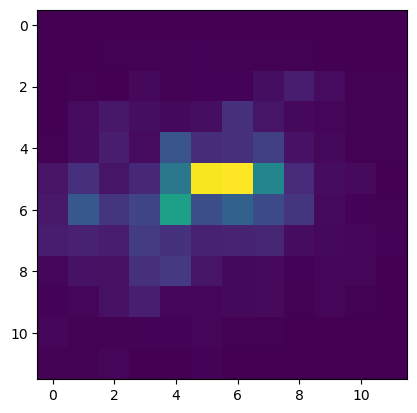

In [4]:
file = filenames[0]
with fits.open(file) as hdul:
    img = hdul[1].data
plt.imshow(img)

1 j
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

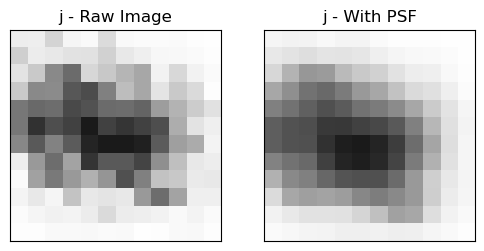

In [5]:
plot_object(1,telescope='euclid',filter='j',catalog=catalog,redshift=redshift)

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

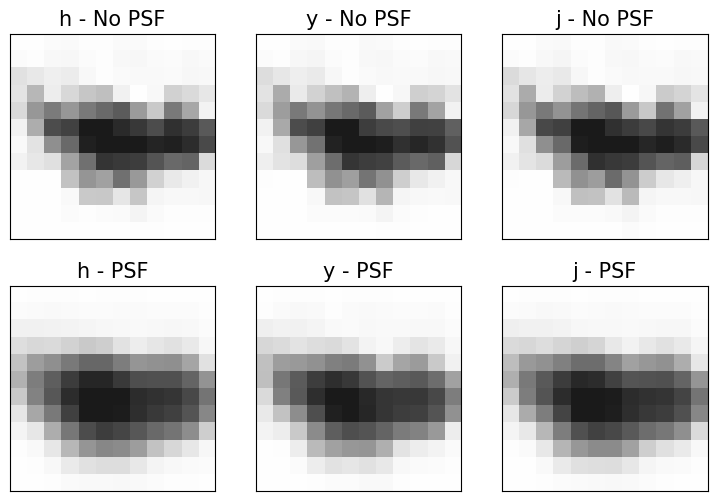

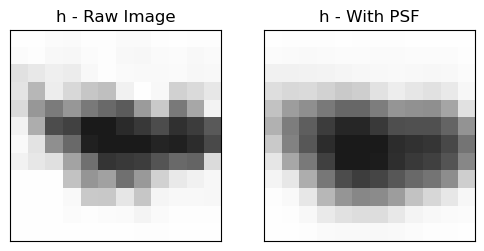

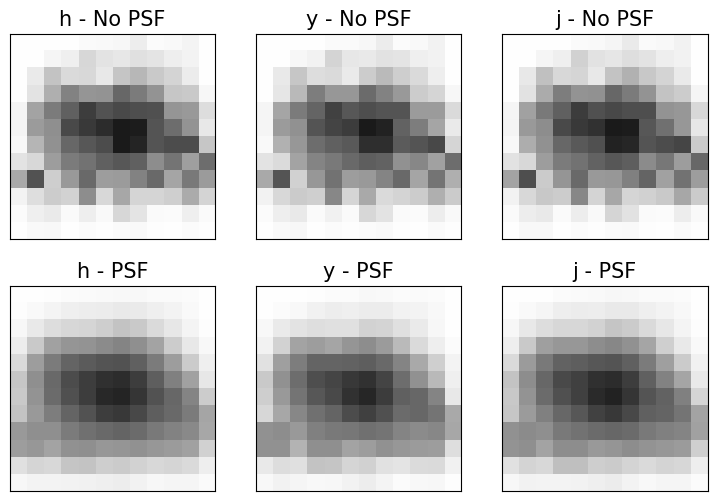

In [7]:
# displaying examples of plot_object(objid,filter,redshift,catalog)
# allowed filters: 'f090w', 'f115w', 'f150w', 'f200w', 'f277w', 'f356w', 'f444w', or 'all'

plot_object(586, telescope='euclid', filter='all', redshift=redshift, catalog=catalog)
plot_object(586, telescope='euclid', filter='h', redshift=redshift, catalog=catalog)
plot_object(3, telescope='euclid', filter='all', redshift=redshift, catalog=catalog)


1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

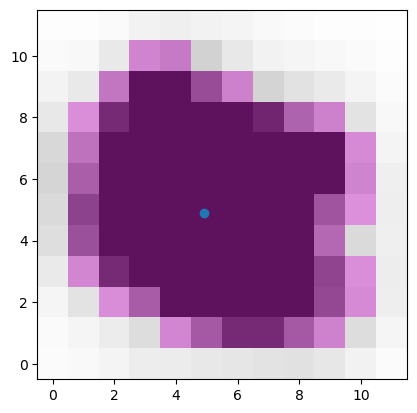

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

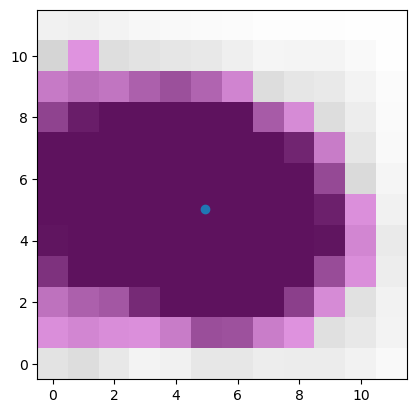

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

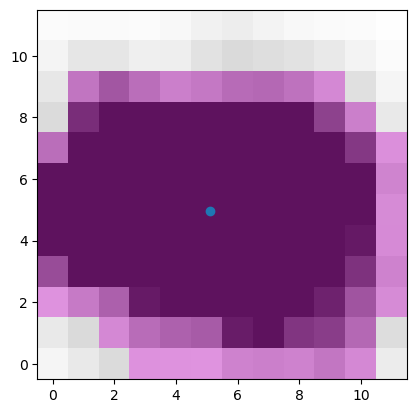

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

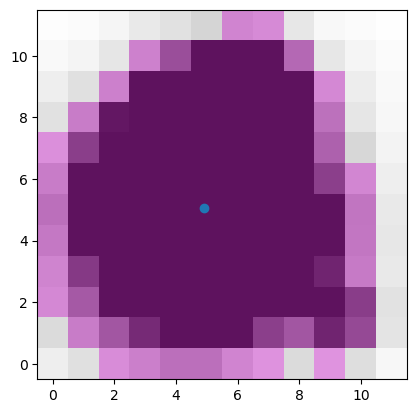

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

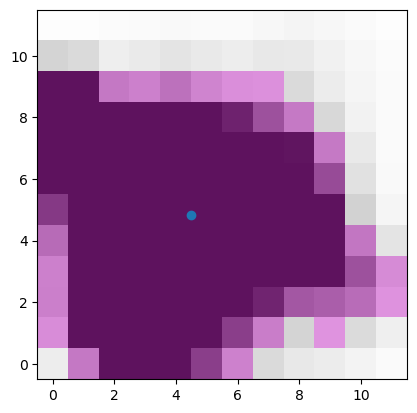

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

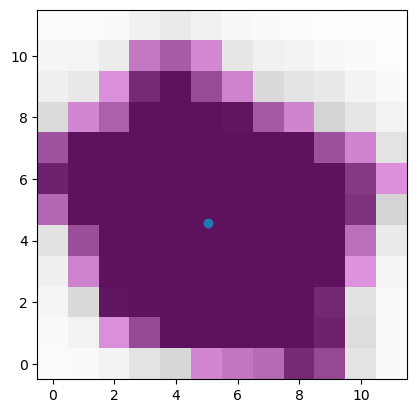

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

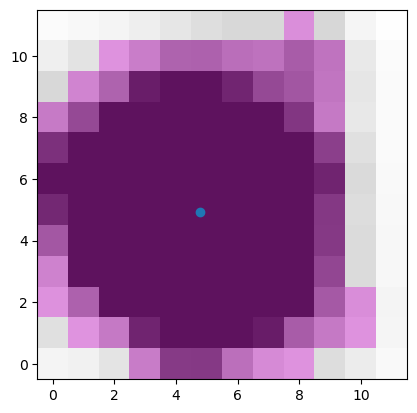

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

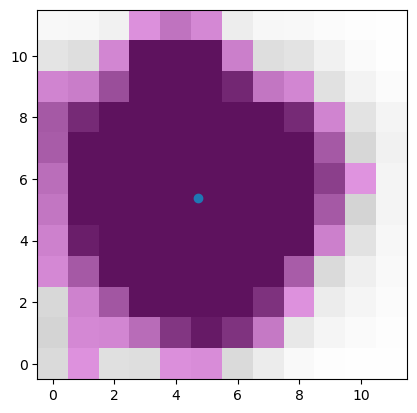

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

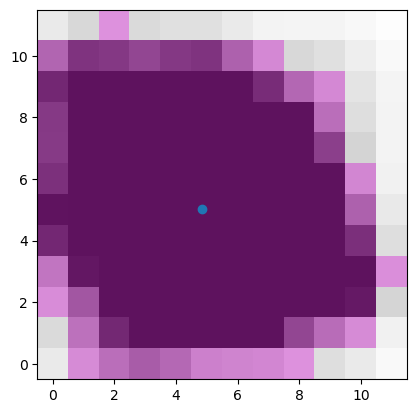

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

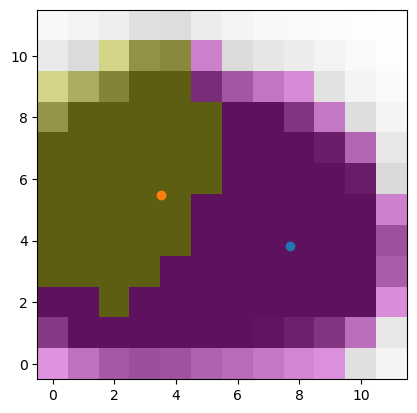

In [15]:
pchi = 0.003
telescope = 'euclid'
noise_level = 0
filter = 'h'
redshift=7

for id in range(20,30):

    img_nopsf, img = grab_image(id, telescope, filter, redshift=7, catalog=catalog)
    img /= np.sum(img)
    img = img.astype(img.dtype.newbyteorder('='))
    # img = add_noise(img,filter,noise_level)

    fig, ax = plt.subplots()
    ax.imshow(img, cmap='RdGy', origin='lower', norm=SymLogNorm(0.1, 1, vmin=-pchi, vmax=pchi))

    objects, seg_map = sep.extract(
        img, 
        thresh=0.0008, 
        minarea=20, 
        filter_kernel=None, 
        deblend_nthresh=32, 
        deblend_cont=1e-3, 
        clean_param=0.01, 
        segmentation_map=True
        )    
    object_mask = seg_map
    print(np.unique(object_mask))

    # 'objects' is a structured array containing information about each detected object
    for obj in objects:
        x = obj['x']
        y = obj['y']
        area = obj['npix']
        flux = obj['flux']
    
        print(f"ID:{id}, Object at (x, y): ({x:.2f}, {y:.2f}), Area: {area, obj['tnpix']}, Flux: {flux:.2f}")
        ax.scatter(obj['x'],obj['y'])
        

    object_mask = object_mask.astype(np.float32)
    object_mask[object_mask==0] = np.nan
    ax.imshow(object_mask, cmap='spring', alpha=0.3, origin='lower')

    plt.show()

In [17]:
### measure the areas of each detected galaxy, the x and y position to get distance, and the flux

def sep_detection(image,band,det_kernel_size,psf): 
    """
    Used to detect galaxies in images from BlueTides Image Catalog

    det_kernel_size = array of Gaussian kernel width for convolution 

    records positions of centroids (pixels), area of galaxies (pixels^2), 
    and fluxes of galaxies (erg/cm^2)
    
    """
    conv_list = []
    x_list = []
    y_list = []
    flux_list = []
    area_list = []
  
    for i, det_k in enumerate(det_kernel_size): 

        if det_k == 0:
            conv_img = image
        else:
            conv_img = convolve_fft(image, Gaussian2DKernel(det_k))

        # conv_img /= np.sum(conv_img)
        conv_img = np.ascontiguousarray(conv_img)
      
        objects, seg_map = sep.extract(
            conv_img, 
            thresh=0.0005, 
            minarea=50, 
            filter_kernel=None, 
            deblend_nthresh=64, 
            deblend_cont=1e-3, 
            clean_param=0.01, 
            segmentation_map=True
            )
               
        x_hold = np.array([obj['x'] for obj in objects])
        y_hold = np.array([obj['y'] for obj in objects])
        area_hold = np.array([obj['npix'] for obj in objects])
        flux_hold = np.array([obj['flux'] for obj in objects])
            
        conv_list.append(det_k)
        x_list.append(x_hold)
        y_list.append(y_hold)
        area_list.append(area_hold)
        flux_list.append(flux_hold)

    binary_output = {"convolutions": conv_list, 
                     "x_pos": x_list,
                     "y_pos": y_list,
                    "areas": area_list,
                    "fluxes": flux_list
                     }

    return binary_output

In [18]:
all_rows = []

noise_level = 0
telescope = 'euclid'
filter = 'h'
det_kernel_size = [0,0.5,1,2,5] # convolution kernel sizes

# first 1000 galaxies
for id in range(1, 1000):
    # grab images
    print(id)
    img_nopsf, img = grab_image(
        id,
        telescope,
        filter,
        redshift,
        catalog,  
        )
    
    # change byte order
    img = img.astype(img.dtype.newbyteorder('='))
    img_nopsf = img_nopsf.astype(img_nopsf.dtype.newbyteorder('='))
    
    if (noise_level>0):
        img = add_noise(img,filter,noise_level=noise_level)

    try:
        # pulling values from catalog for table
        idx = list(catalog['id']).index(id)
        halo_mass    = catalog['haloMass'][idx]
        bh_mass      = catalog['BHmass'][idx]
        stellar_mass = catalog['stellarMass'][idx]
        lum_fuv      = catalog['lum_FUV'][idx]
    except ValueError:
        print(f"ID {id} not found in catalog.")
        continue

    # run sep_detection() for image without psf
    nopsf_info = sep_detection(
        img_nopsf, 
        filter, 
        det_kernel_size=det_kernel_size, 
        psf=False
        )
    
    # extract sep_detection() results
    c = nopsf_info['convolutions']     
    x = nopsf_info['x_pos'] 
    y = nopsf_info['y_pos']
    a = nopsf_info['areas']
    f = nopsf_info['fluxes']      

    # add values to table
    for i in range(len(c)):
        row = {
            'id': id,
            'haloMass': halo_mass,
            'bhMass': bh_mass,
            'stellarMass': stellar_mass,
            'lumFUV': lum_fuv,
            'convolution': c[i],
            'x_pos': x[i],
            'y_pos': y[i],
            'areas': a[i],
            'fluxes': f[i],
            'has_psf': False
        }
        all_rows.append(row)

    plt.pause(0.001)
    
    # run sep_detection() for image with psf
    psf_info = sep_detection(
        img, 
        filter,
        det_kernel_size=det_kernel_size,
        psf=True
        )

    # extract sep_detection() results
    c = psf_info['convolutions']     
    x = psf_info['x_pos']
    y = psf_info['y_pos']
    a = psf_info['areas']
    f = psf_info['fluxes']         

    # add values to table
    for i in range(len(c)):
        row = {
            'id': id,
            'haloMass': halo_mass,
            'bhMass': bh_mass,
            'stellarMass': stellar_mass,
            'lumFUV': lum_fuv,
            'convolution': c[i],
            'x_pos': x[i],
            'y_pos': y[i],
            'areas': a[i],
            'fluxes': f[i],
            'has_psf': True
        }
        all_rows.append(row)

    plt.pause(0.001)

roc_Table = Table(all_rows)
roc_Table


1
1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid

id,haloMass,bhMass,stellarMass,lumFUV,convolution,x_pos,y_pos,areas,fluxes,has_psf
int64,float64,float64,float64,float64,float64,object,object,object,object,bool
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.0,[4.79403396],[5.51518187],[144],[175.96250916],False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.5,[4.80836241],[5.51035422],[144],[175.21948242],False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,1.0,[4.85740088],[5.49862529],[144],[172.79415894],False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,2.0,[4.9807985],[5.47804178],[144],[163.95613098],False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,5.0,[5.26954201],[5.49243284],[144],[95.65100098],False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.0,[4.40329979],[5.00481478],[144],[171.93556213],True
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.5,[4.42799551],[5.0035368],[144],[170.86254883],True
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,1.0,[4.49507443],[5.00260993],[144],[167.80735779],True
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,2.0,[4.65387749],[5.03375764],[144],[157.78382874],True


In [19]:
# cleaning the table
distances = []
flux_ratios = []
area_1 = []
area_2 = []

for row in all_rows:
    x = row['x_pos']
    y = row['y_pos']
    areas = row['areas']
    fluxes = row['fluxes']

    if len(areas) <= 1: # no pair case
        distances.append(0.0)
        flux_ratios.append(0.0)
        area_1.append(0.0)
        area_2.append(0.0)
    else:
        # Filter areas > 20 pixels
        valid_indices = np.where(areas > 20)[0]

        if len(valid_indices) < 2:
            distances.append(0.0)
            flux_ratios.append(0.0)
            area_1.append(0.0)
            area_2.append(0.0)
        else:
            # Get top 2 largest areas and their indices
            top_indices = valid_indices[np.argsort(areas[valid_indices])[-2:]]

            x1, y1 = x[top_indices[0]], y[top_indices[0]]
            x2, y2 = x[top_indices[1]], y[top_indices[1]]
            a1, a2 = areas[top_indices[0]], areas[top_indices[1]]
            f1, f2 = fluxes[top_indices[0]], fluxes[top_indices[1]]

            # calculate distances between centroids
            dist = np.hypot(x2 - x1, y2 - y1)
            distances.append(dist)

            area_1.append(a1)
            area_2.append(a2)

            flux_ratio = min(f1, f2) / max(f1, f2)
            flux_ratios.append(flux_ratio)

# Add the computed distances to the trimmed table
roc_Table['distances'] = distances
roc_Table['flux_ratio'] = flux_ratios
roc_Table['area_1'] = area_1
roc_Table['area_2'] = area_2
roc_Table

id,haloMass,bhMass,stellarMass,lumFUV,convolution,x_pos,y_pos,areas,fluxes,has_psf,distances,flux_ratio,area_1,area_2
int64,float64,float64,float64,float64,float64,object,object,object,object,bool,float64,float64,float64,float64
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.0,[4.79403396],[5.51518187],[144],[175.96250916],False,0.0,0.0,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.5,[4.80836241],[5.51035422],[144],[175.21948242],False,0.0,0.0,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,1.0,[4.85740088],[5.49862529],[144],[172.79415894],False,0.0,0.0,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,2.0,[4.9807985],[5.47804178],[144],[163.95613098],False,0.0,0.0,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,5.0,[5.26954201],[5.49243284],[144],[95.65100098],False,0.0,0.0,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.0,[4.40329979],[5.00481478],[144],[171.93556213],True,0.0,0.0,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.5,[4.42799551],[5.0035368],[144],[170.86254883],True,0.0,0.0,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,1.0,[4.49507443],[5.00260993],[144],[167.80735779],True,0.0,0.0,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,2.0,[4.65387749],[5.03375764],[144],[157.78382874],True,0.0,0.0,0.0,0.0


In [20]:
roc_Table[roc_Table['distances']!=0]

id,haloMass,bhMass,stellarMass,lumFUV,convolution,x_pos,y_pos,areas,fluxes,has_psf,distances,flux_ratio,area_1,area_2
int64,float64,float64,float64,float64,float64,object,object,object,object,bool,float64,float64,float64,float64
11,1078433700000.0,185883540.0,52658627000.0,3.521241853418743e+29,0.0,[5.27054295 2.56981823 0.31144257],[5.206125 6.55328253 3.26643966],[58 60 26],[137.64573669 102.57646179 46.57295227],False,3.0180701464462527,0.7452207693128876,58.0,60.0
11,1078433700000.0,185883540.0,52658627000.0,3.521241853418743e+29,0.5,[5.28810835 2.55939916],[5.24190078 6.5299039 ],[64 80],[139.98866272 144.55885315],False,3.0174170884374285,0.9683852608808137,64.0,80.0
29,1527851600000.0,147924700.0,48490844000.0,4.446071345840014e+29,0.0,[8.2687933 4.20416622 0.75751395],[4.26595594 5.79631778 4.1513006 ],[60 41 43],[176.6118927 118.79718781 68.40164185],False,7.512154370454371,0.3872991835369617,43.0,60.0
29,1527851600000.0,147924700.0,48490844000.0,4.446071345840014e+29,0.5,[8.2530835 4.20873442 0.66025918],[4.30348604 5.77891995 4.00265611],[61 56 27],[179.23214722 137.57019043 44.76547623],False,4.305074295207141,0.7675531011927474,56.0,61.0
29,1527851600000.0,147924700.0,48490844000.0,4.446071345840014e+29,0.0,[7.76279576 3.34325033],[3.72709396 5.3269847 ],[111 33],[251.5569458 100.52496338],True,4.700216187684976,0.3996111618341729,33.0,111.0
29,1527851600000.0,147924700.0,48490844000.0,4.446071345840014e+29,0.5,[7.68522985 3.49911886],[3.84213372 5.48099717],[102 42],[215.05032349 134.23933411],True,4.495486470548987,0.6242228885323189,42.0,102.0
40,621614500000.0,104495100.0,24702530000.0,9.16168826259684e+28,0.0,[10.40195807 5.26247744],[6.08897949 5.29839004],[ 21 122],[ 7.90753651 61.72216415],False,5.199931996122949,0.12811502342847803,21.0,122.0
47,716459150000.0,202959950.0,30258164000.0,1.5827880081986593e+29,0.0,[5.27299361 9.84505298],[5.07011326 8.8398512 ],[121 23],[120.6680069 20.49504471],True,5.925761638641494,0.16984655034329682,23.0,121.0
47,716459150000.0,202959950.0,30258164000.0,1.5827880081986593e+29,0.5,[5.31561048 9.83566105],[5.0712558 8.84030041],[121 23],[120.65486908 19.6767292 ],True,5.885282863137386,0.1630827612045294,23.0,121.0


In [21]:
# constructing final table - copy rows from roc_Table

sep_table = Table()
sep_table['id'] = roc_Table['id'] 
sep_table['haloMass'] = roc_Table['haloMass'] 
sep_table['bhMass'] = roc_Table['bhMass'] 
sep_table['stellarMass'] = roc_Table['stellarMass'] 
sep_table['lumFUV'] = roc_Table['lumFUV'] 
sep_table['convolution'] = roc_Table['convolution'] 
sep_table['distances'] = roc_Table['distances'] 
sep_table['flux_ratio'] = roc_Table['flux_ratio'] 
sep_table['area_1'] = roc_Table['area_1'] 
sep_table['area_2'] = roc_Table['area_2'] 
sep_table['has_psf'] = roc_Table['has_psf'] 

sep_table.write(f'{code_path}/sep_table_h.ecsv', overwrite=True) 
sep_table

id,haloMass,bhMass,stellarMass,lumFUV,convolution,distances,flux_ratio,area_1,area_2,has_psf
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.0,0.0,0.0,0.0,0.0,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.5,0.0,0.0,0.0,0.0,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,1.0,0.0,0.0,0.0,0.0,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,2.0,0.0,0.0,0.0,0.0,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,5.0,0.0,0.0,0.0,0.0,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.0,0.0,0.0,0.0,0.0,True
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.5,0.0,0.0,0.0,0.0,True
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,1.0,0.0,0.0,0.0,0.0,True
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,2.0,0.0,0.0,0.0,0.0,True


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import numpy as np

pchi = 0.0015
noise_level = 0
filter = 'f150w'
redshift = 7
det_kernel_size = [0, 0.5, 1, 2, 5]

for id in [511,987]:  # just one object

    # Load and normalize images
    img_nopsf, img = grab_image(id, filter, catalog=catalog, redshift=redshift)
    img_nopsf /= np.sum(img_nopsf)
    img /= np.sum(img)
    img_nopsf = img_nopsf.astype(img.dtype.newbyteorder('='))
    img = img.astype(img.dtype.newbyteorder('='))

    # Set up plot
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    # ==== RAW IMAGE ====

    ax = axs[0, 0]

    conv_img_nopsf = convolve_fft(img_nopsf, Gaussian2DKernel(1))
    conv_img_nopsf /= np.sum(conv_img_nopsf)
    conv_img_nopsf = conv_img_nopsf.astype(conv_img_nopsf.dtype.newbyteorder('='))
    
    # no convolution
    ax.imshow(img_nopsf, cmap='RdGy', origin='lower',
              norm=SymLogNorm(0.5, 1, vmin=-pchi, vmax=pchi))

    objects, seg_map = sep.extract(
            img_nopsf, thresh=0.0005, minarea=50,
            filter_kernel=None, deblend_nthresh=64, deblend_cont=1e-3,
            clean_param=0.01, segmentation_map=True)

    # with convolution
    # ax.imshow(conv_img_nopsf, cmap='RdGy', origin='lower',
    #           norm=SymLogNorm(0.5, 1, vmin=-pchi, vmax=pchi))

    # objects, seg_map = sep.extract(
    #     conv_img_nopsf, thresh=0.0005*5, minarea=10,
    #     filter_kernel=None, deblend_nthresh=32, deblend_cont=1,
    #     clean_param=0.01, segmentation_map=True, clean=False,
    # )

    object_mask = seg_map

    for obj in objects:
        x = obj['x']
        y = obj['y']
        area = obj['npix']
        tarea = obj['tnpix']
        flux = obj['flux']
        print(f"RAW Image - ID:{id}, Object at (x, y): ({x:.2f}, {y:.2f}), Area: {area}, Tarea: {tarea}, Flux: {flux:.2f}")
        ax.scatter(x, y, s=20)

    object_mask = object_mask.astype(np.float32)
    object_mask[object_mask == 0] = np.nan
    ax.imshow(object_mask, cmap='spring', alpha=0.3, origin='lower')
    ax.set_title("Raw Image (No PSF)")
    ax.grid()
    # break

    # ==== PSF-CONVOLVED IMAGES ====
    psf_info = sep_detection(img, det_kernel_size=det_kernel_size)

    for i, det_k in enumerate(det_kernel_size):
        row = (i + 1) // 3
        col = (i + 1) % 3
        ax = axs[row, col]

        if det_k == 0:
            conv_img = img.copy()
        else:
            conv_img = convolve_fft(img, Gaussian2DKernel(det_k))
        conv_img /= np.sum(conv_img)
        conv_img = conv_img.astype(conv_img.dtype.newbyteorder('='))

        ax.imshow(conv_img, cmap='RdGy', origin='lower',
                  norm=SymLogNorm(0.5, 1, vmin=-pchi, vmax=pchi))

        x_list = psf_info['x_pos'][i]
        y_list = psf_info['y_pos'][i]
        areas = psf_info['areas'][i]
        fluxes = psf_info['fluxes'][i]

        for x, y, area, flux in zip(x_list, y_list, areas, fluxes):
            print(f"PSF (k={det_k}) - ID:{id}, Object at (x, y): ({x:.2f}, {y:.2f}), Area: {area}, Flux: {flux:.2f}")
            ax.scatter(x, y, s=20, c='orange')

        for obj in objects:
            x = obj['x']
            y = obj['y']
            area = obj['npix']
            flux = obj['flux']
            # print(f"RAW Image - ID:{id}, Object at (x, y): ({x:.2f}, {y:.2f}), Area: {area}, Flux: {flux:.2f}")
            ax.scatter(x, y, s=20, c='blue')


        _, seg_map = sep.extract(
            conv_img, thresh=0.0005, minarea=50,
            filter_kernel=None, deblend_nthresh=64, deblend_cont=1e-3,
            clean_param=0.01, segmentation_map=True
        )
        seg_map = seg_map.astype(np.float32)
        seg_map[seg_map == 0] = np.nan
        ax.imshow(seg_map, cmap='spring', alpha=0.3, origin='lower')

        ax.set_title(f"PSF Convolved (Kernel = {det_k})")
        ax.grid()

    plt.tight_layout()
    plt.show()


update plotting so images show with different convolution 